In [1]:
# Torch Library
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch import optim
from torch import autograd
from torch.autograd import Variable
from torch.autograd import Function
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch.utils.data.sampler import SubsetRandomSampler


In [2]:
# Torchvision Library
import torchvision
from torchvision import transforms
from torchvision import datasets
from torchvision.datasets import CIFAR10


In [3]:
# Common Library
import numpy as np
import random
import os


In [4]:
# Figures Library
from matplotlib import pyplot as plt
from matplotlib import rc
from matplotlib import style 
plt.style.use('seaborn-v0_8')


In [5]:
# SLL Library 
# (SLL model from paper "A Unified Algebraic Perspective on Lipschitz Neural Networks")
# https://github.com/araujoalexandre/Lipschitz-SLL-Networks
# Araujo, Alexandre, et al. "A unified algebraic perspective on lipschitz neural networks." 
# arXiv preprint arXiv:2303.03169 (2023).

from SLL.models.model import NormalizedModel
from SLL.models.model import LipschitzNetwork
from SLL.data.readers import readers_config
from SLL.models.layers import SDPBasedLipschitzConvLayer
from SLL.models.layers import SDPBasedLipschitzLinearLayer


In [6]:
# Pretrained ResNet18 Library
# https://huggingface.co/docs/timm/en/index

import detectors
import timm

In [7]:
# Cuda Library 

cudnn.benchmark = True
device = torch.device("cuda:0")


In [8]:
# Inputs Perturbation

def eval_Gaussian_inputs(model, reader, sigma):
    # Define the standard deviation of the Gaussian noise
    stddev = sigma
    # Create a list to store the adversarial examples and their corresponding labels
    adversarial_examples = []
    # Loop over the test set and add Gaussian noise to each image
    for images, labels in reader:
        # Add Gaussian noise to the image
        nimages = images + torch.randn(images.size()) * stddev
        # Append the adversarial example and its label to the list
        adversarial_examples.append((nimages, labels))
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in adversarial_examples:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            accuracy = correct / total
    return accuracy

In [9]:
# Outputs Peturbation 

def eval_Gaussian_outputs(model, reader, sigma):

    model.eval()
    running_accuracy = 0
    running_inputs = 0
    
    for batch_n, data in enumerate(reader):
        inputs, labels = data
        inputs, labels = inputs.cuda(), labels.cuda()

        outputs = model(inputs)
        noise = torch.randn_like(outputs) * sigma
        outputs += noise
        
        predicted = outputs.argmax(axis=1)
        correct = outputs.max(1)[1] == labels
        running_accuracy += predicted.eq(labels.data).cpu().sum().numpy()
        running_inputs += inputs.size(0)
        
    accuracy = running_accuracy / running_inputs
    return accuracy

In [10]:
# Mixed Peturbation 

def eval_Gaussian_mixed(model, reader, sigma):
    
    # Define the standard deviation of the Gaussian noise
    stddev = sigma
    # Create a list to store the adversarial examples and their corresponding labels
    adversarial_examples = []
    # Loop over the test set and add Gaussian noise to each image
    for images, labels in reader:
        # Add Gaussian noise to the image
        nimages = images + torch.randn(images.size()) * stddev
        # Append the adversarial example and its label to the list
        adversarial_examples.append((nimages, labels))
    
    model.eval()
    running_accuracy = 0
    running_inputs = 0
    
    for batch_n, data in enumerate(adversarial_examples):
        inputs, labels = data
        inputs, labels = inputs.cuda(), labels.cuda()

        outputs = model(inputs)
        noise = torch.randn_like(outputs) * sigma
        outputs += noise
        
        predicted = outputs.argmax(axis=1)
        correct = outputs.max(1)[1] == labels
        running_accuracy += predicted.eq(labels.data).cpu().sum().numpy()
        running_inputs += inputs.size(0)
        
    accuracy = running_accuracy / running_inputs
    return accuracy

In [11]:
# Average

def average_eval_Gaussian_inputs(model, reader, sigma, count):
    ## Average :
    counter = 0
    result = list()

    while counter < count:
        random.seed(counter)
        result_acc = eval_Gaussian_inputs(model, reader, sigma)
        result.append(result_acc)
        counter+= 1

    average = np.average(result)
    std= np.std(result)
    return average, std

def average_eval_Gaussian_outputs(model, reader, sigma, count):
    ## Average :
    counter = 0
    result = list()

    while counter < count:
        random.seed(counter)
        result_acc = eval_Gaussian_outputs(model, reader, sigma)
        result.append(result_acc)
        counter+= 1

    average = np.average(result)
    std= np.std(result)
    return average, std

def average_eval_Gaussian_mixed(model, reader, sigma, count):
    ## Average :
    counter = 0
    result = list()

    while counter < count:
        random.seed(counter)
        result_acc = eval_Gaussian_mixed(model, reader, sigma)
        result.append(result_acc)
        counter+= 1

    average = np.average(result)
    std= np.std(result)
    return average, std

In [12]:
# SLLsmall config

class Config:

  def __init__(self, dataset, size):
    self.mode = 'certified'
    self.dataset = dataset
    self.ngpus = 4
    self.batch_size = 500
    self.shift_data = True

    config = self.set_archi(20, 7, 45, 2048)

  def set_archi(self, n_conv, n_dense, w, dense_inner_dim):
    self.n_conv = n_conv
    self.n_dense = n_dense
    self.conv_inner_dim = 5
    self.dense_inner_dim = dense_inner_dim
    self.w = w 

# SLLsmall data import

config = Config('cifar10', 'small')
Reader = readers_config['cifar10']
reader = Reader(config, 256, False, is_training=False)
data_loader, _ = reader.load_dataset()

# SLLsmall model import

modelsmall = LipschitzNetwork(config, reader.n_classes)
modelsmall = NormalizedModel(modelsmall, reader.means, reader.stds)
modelsmall = torch.nn.DataParallel(modelsmall)
modelsmall.load_state_dict(torch.load('SLL/modelsmall.ckpt')['model_state_dict'])
modelsmall = modelsmall.cuda()


In [13]:
# test SLL small:

## no-noise
SLLsmall_in = eval_Gaussian_inputs(modelsmall, data_loader, 0)
SLLsmall_out = eval_Gaussian_outputs(modelsmall, data_loader, 0)
print(SLLsmall_out, SLLsmall_in)

# Perfect

0.7157 0.7157


In [14]:
# Pre-Trained ResNet18 import

model18 = timm.create_model("resnet18_cifar10", pretrained=True)
model18 = model18.to(device)

# ResNet18 config import

transform = timm.data.create_transform(
    **timm.data.resolve_data_config(model18.pretrained_cfg)
)

# ResNet18 data import

new_dataset = CIFAR10('./data', train=False, transform=transform)
new_loader = torch.utils.data.DataLoader(new_dataset, batch_size=500,
    num_workers=0)

In [15]:
# test ResNet18:

## no-noise
ResNet18_out = eval_Gaussian_outputs(model18, new_loader, 0)
ResNet18_in = eval_Gaussian_inputs(model18, new_loader, 0)

print(ResNet18_out, ResNet18_in)

# Perfect

0.9498 0.9498


In [16]:
torch.cuda.empty_cache()

In [17]:
## Function to grid search

def optimum_resnet_Gaussian_input (reader, sigma, count):
    ## targeted IP constraints
    delta = 0.00001
    mu = 1
    
    target_epsilon_levels = [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3]
    target_alpha_levels = [0.1]
    
    # fixed search alpha_levels
    
    # alpha_levels = [0.001, 0.01, 0.1]
    alpha_levels = [0.1]

    ## Accuracy count
    accuracy_count = 0
    stddev_count = 0

    for target_epsilon in target_epsilon_levels:
        
        # generate training epsilon from target epsilon levels
        quarter_epsilon = target_epsilon * 0.25
        half_epsilon = target_epsilon * 0.5
        high_epsilon = target_epsilon * 1.15
        low_epsilon = target_epsilon * 0.85
        twice_epsilon = target_epsilon * 2
        epsilon_levels = [quarter_epsilon, half_epsilon, low_epsilon, target_epsilon, high_epsilon, twice_epsilon]
        # epsilon_levels = [half_epsilon]
        
        for target_alpha in target_alpha_levels:
        
            for epsilon in epsilon_levels:
            
                for alpha in alpha_levels: 
                                    
                    model = timm.create_model("resnet18_cifar10", pretrained=True)
                    model = model.to(device)
                    model.load_state_dict(torch.load(f'Tuning/model_cifar_ep_{epsilon}_al_{alpha}_target_ep_{target_epsilon}_target_al_{target_alpha}.pt'))
                        
                    targeted_accuracy, targeted_stddev = average_eval_Gaussian_inputs(model, reader, sigma, count)
                    
                    if targeted_accuracy > accuracy_count:
                        accuracy_count = targeted_accuracy
                        stddev_count = targeted_stddev

    return accuracy_count, stddev_count



In [ ]:
## Figure 1: fix mechanism, show impact of increasing radius on accuracy vs privacy budget

In [25]:
# Graph for various alpha:

## initial IP constraints
delta = 0.00001
epsilon = 0.5
mu = 1
count = 15

alpha_0 = 0
alpha_1 = 0.05
alpha_2 = 0.07
alpha_3 = 0.1
alpha_4 = 0.2


## prepare list
SLLsmall_out_line_0 =list()
SLLsmall_out_line_1 =list()
SLLsmall_out_line_2 =list()
SLLsmall_out_line_3 =list()
SLLsmall_out_line_4 =list()

SLLsmall_out_err_0 = list()
SLLsmall_out_err_1 = list()
SLLsmall_out_err_2 = list()
SLLsmall_out_err_3 = list()
SLLsmall_out_err_4 = list()
## For different alpha:

while epsilon < 5.5:

    ## determine sigma
    sigma_0 = np.sqrt(2*np.log(1.25/delta))*alpha_0*mu/epsilon
    sigma_1 = np.sqrt(2*np.log(1.25/delta))*alpha_1*mu/epsilon
    sigma_2 = np.sqrt(2*np.log(1.25/delta))*alpha_2*mu/epsilon
    sigma_3 = np.sqrt(2*np.log(1.25/delta))*alpha_3*mu/epsilon
    sigma_4 = np.sqrt(2*np.log(1.25/delta))*alpha_4*mu/epsilon
    
    SLLsmall_out_average_0, SLLsmall_out_std_0 = average_eval_Gaussian_outputs(modelsmall, data_loader, sigma_0, count)
    SLLsmall_out_average_1, SLLsmall_out_std_1 = average_eval_Gaussian_outputs(modelsmall, data_loader, sigma_1, count)
    SLLsmall_out_average_2, SLLsmall_out_std_2 = average_eval_Gaussian_outputs(modelsmall, data_loader, sigma_2, count)
    SLLsmall_out_average_3, SLLsmall_out_std_3 = average_eval_Gaussian_outputs(modelsmall, data_loader, sigma_3, count)
    SLLsmall_out_average_4, SLLsmall_out_std_4 = average_eval_Gaussian_outputs(modelsmall, data_loader, sigma_4, count)


    ## append list 
    SLLsmall_out_line_0.append(SLLsmall_out_average_0)
    SLLsmall_out_err_0.append(SLLsmall_out_std_0)

    SLLsmall_out_line_1.append(SLLsmall_out_average_1)
    SLLsmall_out_err_1.append(SLLsmall_out_std_1)

    SLLsmall_out_line_2.append(SLLsmall_out_average_2)
    SLLsmall_out_err_2.append(SLLsmall_out_std_2)

    SLLsmall_out_line_3.append(SLLsmall_out_average_3)
    SLLsmall_out_err_3.append(SLLsmall_out_std_3)

    SLLsmall_out_line_4.append(SLLsmall_out_average_4)
    SLLsmall_out_err_4.append(SLLsmall_out_std_4)
    

    epsilon=epsilon+0.05

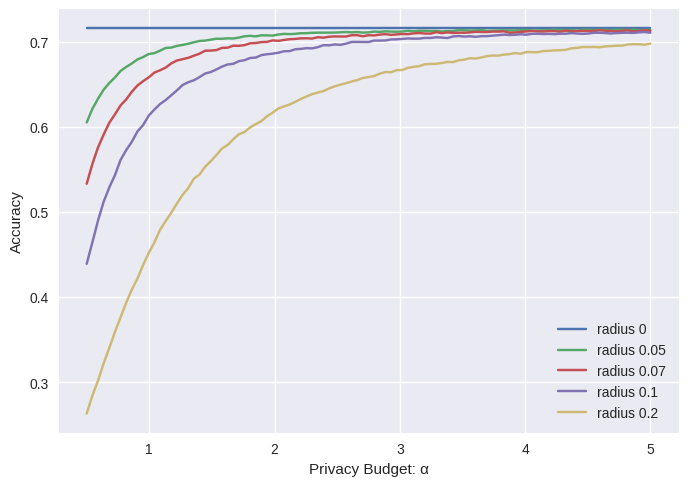

In [26]:
epsilon_list= np.linspace(0.5, 5, num=101)

plt.plot(epsilon_list, SLLsmall_out_line_0, label ='radius 0')


plt.plot(epsilon_list, SLLsmall_out_line_1, label ='radius 0.05')
#plt.fill_between(epsilon_list, SLLsmall_out_lower_1, SLLsmall_out_upper_1 , alpha=0.2, label='Error region')

plt.plot(epsilon_list, SLLsmall_out_line_2, label ='radius 0.07')
#plt.fill_between(epsilon_list, SLLsmall_out_lower_2, SLLsmall_out_upper_2 , alpha=0.2, label='Error region')

plt.plot(epsilon_list, SLLsmall_out_line_3, label ='radius 0.1')
#plt.fill_between(epsilon_list, SLLsmall_out_lower_3, SLLsmall_out_upper_3 , alpha=0.2, label='Error region')

plt.plot(epsilon_list, SLLsmall_out_line_4, label ='radius 0.2')
#plt.fill_between(epsilon_list, SLLsmall_out_lower_4, SLLsmall_out_upper_4 , alpha=0.2, label='Error region')


plt.xlabel("Privacy Budget: α")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig('Impact of increasing alpha')
plt.show()

In [18]:
torch.cuda.empty_cache()

In [19]:
## Figure 2: fix alpha, show impact of different mechanisms on accuracy vs privacy budget

In [22]:
# Graph for various epsilon:

## initial IP constraints
delta = 0.00001
plot_epsilon = np.linspace(0.5, 5, 19)
mu = 1
count = 15
alpha = 0.2

## prepare list
ResNet18_in_line =list()

ResNet18_tune_in_line =list()

SLLsmall_in_line =list()

SLLsmall_out_line =list()

## For different epsilon:

for epsilon in plot_epsilon:
    ## determine sigma
    sigma = np.sqrt(2*np.log(1.25/delta))*alpha*mu/epsilon

    ResNet18_in_average, ResNet18_in_std = average_eval_Gaussian_inputs(model18, new_loader, sigma, count)

    ResNet18_tune_in_average = optimum_resnet_Gaussian_input (new_loader, sigma, count)

    SLLsmall_out_average, SLLsmall_out_std = average_eval_Gaussian_outputs(modelsmall, data_loader, sigma, count)
    
    SLLsmall_in_average, SLLsmall_in_std = average_eval_Gaussian_inputs(modelsmall, data_loader, sigma, count)

    ## append list 
    ResNet18_in_line.append(ResNet18_in_average)

    ResNet18_tune_in_line.append(ResNet18_tune_in_average)
    
    SLLsmall_out_line.append(SLLsmall_out_average)
    
    SLLsmall_in_line.append(SLLsmall_in_average)


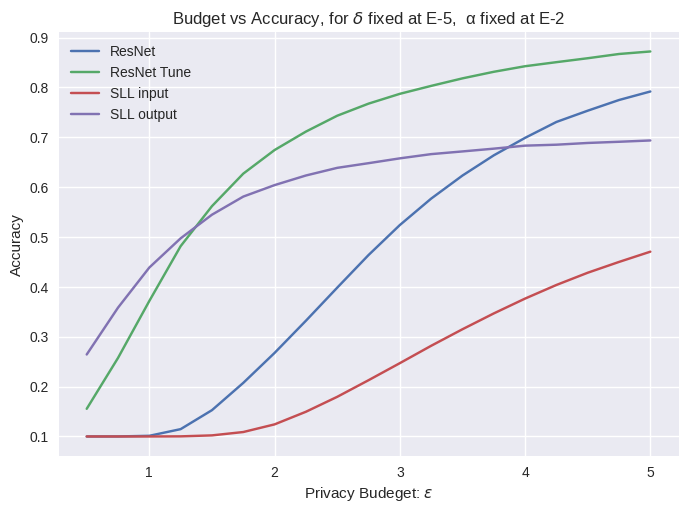

In [23]:
plt.plot(plot_epsilon, ResNet18_in_line, label= "ResNet")
plt.plot(plot_epsilon, ResNet18_tune_in_line, label= "ResNet Tune")
plt.plot(plot_epsilon, SLLsmall_in_line, label= "SLL input")
plt.plot(plot_epsilon, SLLsmall_out_line, label= "SLL output")

plt.xlabel("Privacy Budeget: $\epsilon$")
plt.ylabel("Accuracy")
# plt.legend()
plt.title('Budget vs Accuracy, for $\delta$ fixed at E-5,  α fixed at E-2')
plt.savefig('Budget vs Accuracy, for $\delta$ fixed at E-5,  α fixed at E-2')
plt.show()
plt.show()

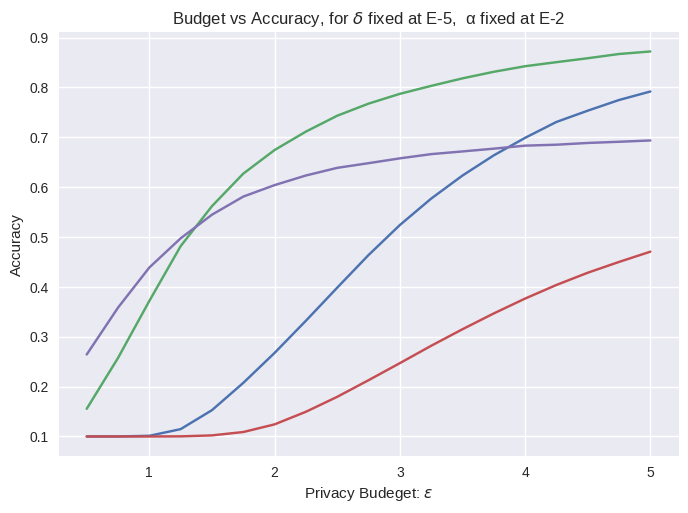

In [24]:
plt.plot(plot_epsilon, ResNet18_in_line)
plt.plot(plot_epsilon, ResNet18_tune_in_line)
plt.plot(plot_epsilon, SLLsmall_in_line)
plt.plot(plot_epsilon, SLLsmall_out_line)

plt.xlabel("Privacy Budeget: $\epsilon$")
plt.ylabel("Accuracy")
# plt.legend()
plt.title('Budget vs Accuracy, for $\delta$ fixed at E-5,  α fixed at E-2')
plt.show()
plt.show()

In [25]:
torch.cuda.empty_cache()

In [26]:
## Figure 3: fix epsilon at 1, show impact of different mechanisms on accuracy vs radisu

In [27]:
# Graph for various alpha:

## initial IP constraints
delta = 0.00001
plot_alpha = np.linspace(0, 0.2, 20)
mu = 1
count = 15
epsilon = 1

## prepare list
ResNet18_in_line =list()

ResNet18_tune_in_line =list()

SLLsmall_in_line =list()

SLLsmall_out_line =list()

## For different epsilon:

for alpha in plot_alpha:
    ## determine sigma
    sigma = np.sqrt(2*np.log(1.25/delta))*alpha*mu/epsilon

    ResNet18_in_average, ResNet18_in_std = average_eval_Gaussian_inputs(model18, new_loader, sigma, count)

    ResNet18_tune_in_average = optimum_resnet_Gaussian_input (new_loader, sigma, count)

    SLLsmall_out_average, SLLsmall_out_std = average_eval_Gaussian_outputs(modelsmall, data_loader, sigma, count)
    
    SLLsmall_in_average, SLLsmall_in_std = average_eval_Gaussian_inputs(modelsmall, data_loader, sigma, count)

    ## append list 
    ResNet18_in_line.append(ResNet18_in_average)

    ResNet18_tune_in_line.append(ResNet18_tune_in_average)
    
    SLLsmall_out_line.append(SLLsmall_out_average)
    
    SLLsmall_in_line.append(SLLsmall_in_average)

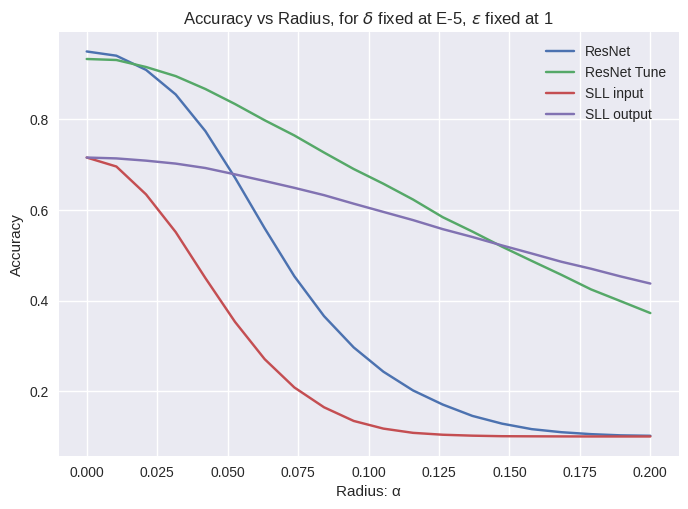

In [28]:
plt.plot(plot_alpha, ResNet18_in_line, label= "ResNet")
plt.plot(plot_alpha, ResNet18_tune_in_line, label= "ResNet Tune")
plt.plot(plot_alpha, SLLsmall_in_line, label= "SLL input")
plt.plot(plot_alpha, SLLsmall_out_line, label= "SLL output")

plt.xlabel("Radius: α")
plt.ylabel("Accuracy")
plt.legend()
plt.title('Accuracy vs Radius, for $\delta$ fixed at E-5, $\epsilon$ fixed at 1')
plt.savefig('Accuracy vs Radius, for $\delta$ fixed at E-5, $\epsilon$ fixed at 1')
plt.show()

In [16]:
torch.cuda.empty_cache()

In [26]:
## Function to grid search

def optimum_resnet_Gaussian_input_table (reader, target_epsilon, target_alpha, count):
    ## targeted IP constraints
    delta = 0.00001
    mu = 1
    
    ## Accuracy count
    accuracy_count = 0
    stddev_count = 0

    sigma = np.sqrt(2*np.log(1.25/delta))*target_alpha*mu/target_epsilon

    # generate training epsilon from target epsilon levels
    half_epsilon = target_epsilon * 0.5
    twice_epsilon = target_epsilon * 2
    epsilon_levels = [half_epsilon, target_epsilon, twice_epsilon]
    
    # generate training alpha from target alpha levels
    half_alpha = target_alpha * 0.5
    twice_alpha = target_alpha * 2
    alpha_levels = [half_alpha, target_alpha, twice_alpha]
    
    for epsilon in epsilon_levels:
        for alpha in alpha_levels: 
                            
            model = timm.create_model("resnet18_cifar10", pretrained=True)
            model = model.to(device)
            model.load_state_dict(torch.load(f'Turning_table/model_cifar_ep_{epsilon}_al_{alpha}_target_ep_{target_epsilon}_target_al_{target_alpha}.pt'))
                
            targeted_accuracy, targeted_stddev = average_eval_Gaussian_inputs(model, reader, sigma, count)
            
            if targeted_accuracy > accuracy_count:
                accuracy_count = targeted_accuracy
                stddev_count = targeted_stddev
                print (f'Turning_table/model_cifar_ep_{epsilon}_al_{alpha}_target_ep_{target_epsilon}_target_al_{target_alpha}')
                    
    return accuracy_count, stddev_count



In [27]:
## Table Genaration

delta = 0.00001
mu = 1
count = 15

table_epsilon = [0.1, 1, 10]
table_alpha = [0.001, 0.01, 0.1, 0.2]


for alpha in table_alpha:
    for epsilon in table_epsilon:

        # Determine specific sigma:
        sigma = np.sqrt(2*np.log(1.25/delta))*alpha*mu/epsilon

        ## regular resnet
        ## ResNet18_in_average, ResNet18_in_std = average_eval_Gaussian_inputs(model18, new_loader, sigma, count)
        ## best tuned resnet
        ResNet18_tune_in_average, ResNet18_tune_in_std = optimum_resnet_Gaussian_input_table (new_loader, epsilon, alpha, count)
        ## SLL output perturbation
        ## SLLsmall_out_average, SLLsmall_out_std = average_eval_Gaussian_outputs(modelsmall, data_loader, sigma, count)
        ## SLL input perturbation
        ## SLLsmall_in_average, SLLsmall_in_std = average_eval_Gaussian_inputs(modelsmall, data_loader, sigma, count)

        print(f'privacy_level_ep_{epsilon}_al_{alpha}')
        
        ## print(format(ResNet18_in_average,'.4f'),      format(ResNet18_in_std,'.4f'))
        print(format(ResNet18_tune_in_average,'.4f'), format(ResNet18_tune_in_std,'.4f'))
        ## print(format(SLLsmall_out_average,'.4f'),     format(SLLsmall_out_std,'.4f'))
        ## print(format(SLLsmall_in_average,'.4f'),      format(SLLsmall_in_std, '.4f'))
        
        print('')


Turning_table/model_cifar_ep_0.05_al_0.0005_target_ep_0.1_target_al_0.001
Turning_table/model_cifar_ep_0.1_al_0.001_target_ep_0.1_target_al_0.001
privacy_level_ep_0.1_al_0.001
0.9321 0.0011

Turning_table/model_cifar_ep_0.5_al_0.0005_target_ep_1_target_al_0.001
Turning_table/model_cifar_ep_1_al_0.002_target_ep_1_target_al_0.001
Turning_table/model_cifar_ep_2_al_0.0005_target_ep_1_target_al_0.001
privacy_level_ep_1_al_0.001
0.9381 0.0003

Turning_table/model_cifar_ep_5.0_al_0.0005_target_ep_10_target_al_0.001
Turning_table/model_cifar_ep_5.0_al_0.001_target_ep_10_target_al_0.001
Turning_table/model_cifar_ep_10_al_0.0005_target_ep_10_target_al_0.001
Turning_table/model_cifar_ep_10_al_0.002_target_ep_10_target_al_0.001
privacy_level_ep_10_al_0.001
0.9374 0.0001

Turning_table/model_cifar_ep_0.05_al_0.005_target_ep_0.1_target_al_0.01
Turning_table/model_cifar_ep_0.05_al_0.01_target_ep_0.1_target_al_0.01
Turning_table/model_cifar_ep_0.05_al_0.02_target_ep_0.1_target_al_0.01
privacy_level_ep